In [1]:
#Step 1: Import Python libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Step 2: Create the data frame
dataframe = pd.read_csv("Zomato data .csv")
print(dataframe.head())

                    name online_order book_table   rate  votes  \
0                  Jalsa          Yes        Yes  4.1/5    775   
1         Spice Elephant          Yes         No  4.1/5    787   
2        San Churro Cafe          Yes         No  3.8/5    918   
3  Addhuri Udupi Bhojana           No         No  3.7/5     88   
4          Grand Village           No         No  3.8/5    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


In [2]:
#Step 3: Understand the structure of the dataset

print("Shape of dataset:", dataframe.shape)
print("\nData types:\n", dataframe.dtypes)
print("\nMissing values:\n", dataframe.isnull().sum())
print("\nSummary statistics:\n", dataframe.describe())

Shape of dataset: (148, 7)

Data types:
 name                           object
online_order                   object
book_table                     object
rate                           object
votes                           int64
approx_cost(for two people)     int64
listed_in(type)                object
dtype: object

Missing values:
 name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

Summary statistics:
              votes  approx_cost(for two people)
count   148.000000                   148.000000
mean    264.810811                   418.243243
std     653.676951                   223.085098
min       0.000000                   100.000000
25%       6.750000                   200.000000
50%      43.500000                   400.000000
75%     221.750000                   600.000000
max    4884

In [16]:
#Step 4: Data Cleaning – Ratings and Cost Conversion

dataframe['rate'] = dataframe['rate'].astype(str)
dataframe['rate'] = dataframe['rate'].apply(lambda x: x.split('/')[0] if '/' in x else x)
dataframe['rate'] = dataframe['rate'].replace(['NEW', '-', 'nan'], np.nan)
dataframe['rate'] = pd.to_numeric(dataframe['rate'], errors='coerce')

dataframe['approx_cost(for two people)'] = dataframe['approx_cost(for two people)'].astype(str)
dataframe['approx_cost(for two people)'] = dataframe['approx_cost(for two people)'].str.replace(',', '')
dataframe['approx_cost(for two people)'] = pd.to_numeric(dataframe['approx_cost(for two people)'], errors='coerce')

print("✅ Sample cleaned data:")
print(dataframe.head())

✅ Sample cleaned data:
                    name online_order book_table  rate  votes  \
0                  Jalsa          Yes        Yes   4.1    775   
1         Spice Elephant          Yes         No   4.1    787   
2        San Churro Cafe          Yes         No   3.8    918   
3  Addhuri Udupi Bhojana           No         No   3.7     88   
4          Grand Village           No         No   3.8    166   

   approx_cost(for two people) listed_in(type)  
0                          800          Buffet  
1                          800          Buffet  
2                          800          Buffet  
3                          300          Buffet  
4                          600          Buffet  


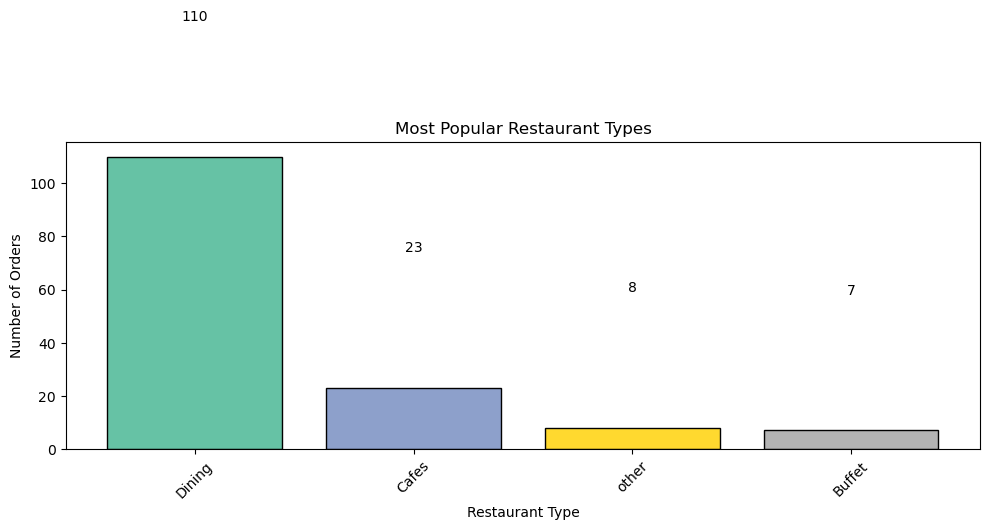

In [13]:
#Step 5: Most Popular Restaurant Types 

plt.figure(figsize=(10, 6))
colors = plt.cm.Set2(np.linspace(0, 1, len(restaurant_type_counts)))

bars = plt.bar(
    restaurant_type_counts['listed_in(type)'],
    restaurant_type_counts['count'],
    color=colors,
    edgecolor='black'
)

# Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 50, str(int(height)),
             ha='center', va='bottom', fontsize=10)

plt.title('Most Popular Restaurant Types')
plt.xlabel('Restaurant Type')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Total votes by restaurant type:
listed_in(type)
Dining    20363
other      9367
Cafes      6434
Buffet     3028
Name: votes, dtype: int64


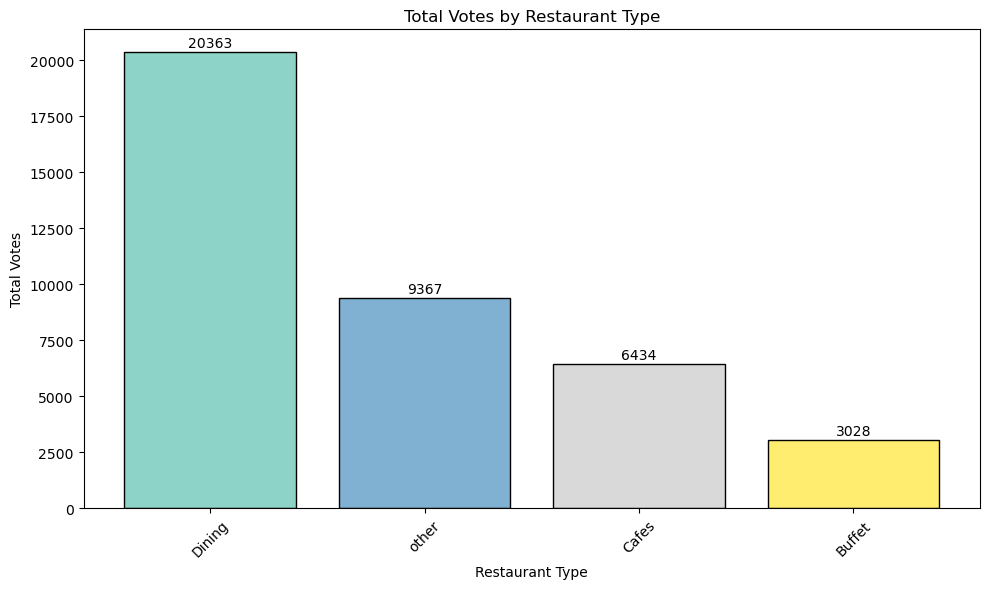

In [6]:

#Step 6: How many votes has each type of restaurant received?

votes_per_type = dataframe.groupby('listed_in(type)')['votes'].sum().sort_values(ascending=False)
print("Total votes by restaurant type:")
print(votes_per_type)

plt.figure(figsize=(10, 6))
x_labels = votes_per_type.index
y_values = votes_per_type.values
colors = plt.cm.Set3(np.linspace(0, 1, len(x_labels)))

bars = plt.bar(x_labels, y_values, color=colors, edgecolor='black')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 100, f'{int(height)}',
             ha='center', va='bottom', fontsize=10)

plt.title('Total Votes by Restaurant Type')
plt.xlabel('Restaurant Type')
plt.ylabel('Total Votes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

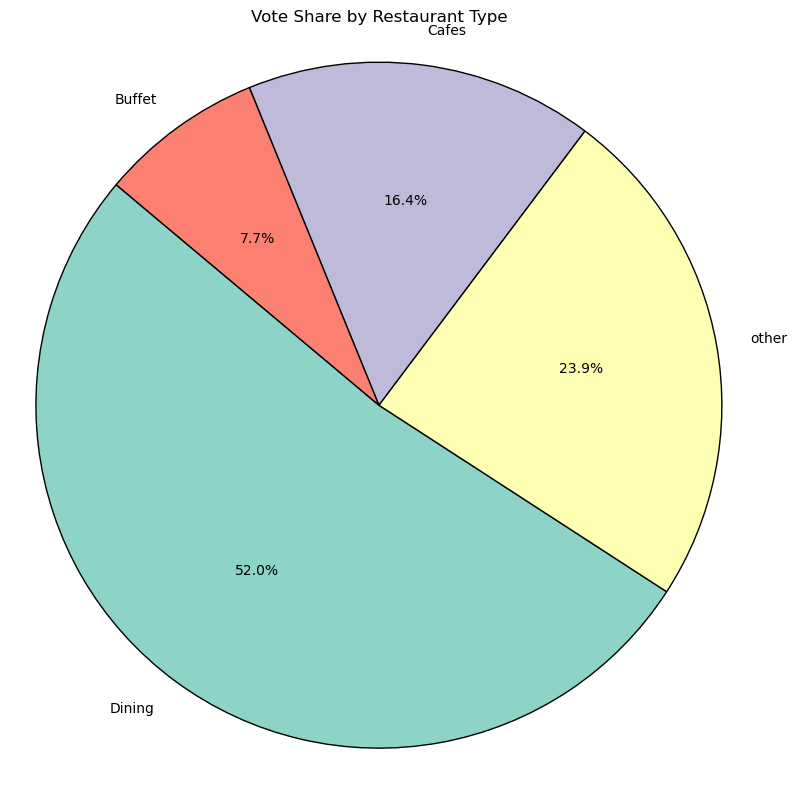

In [7]:
#pie chart

plt.figure(figsize=(8, 8))
colors = sns.color_palette('Set3')

plt.pie(
    votes_per_type,
    labels=votes_per_type.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'black'}
)

plt.title('Vote Share by Restaurant Type')
plt.axis('equal')
plt.tight_layout()
plt.show()

Ratings and their restaurant count:
rate
2.6     1
2.8     2
2.9     7
3.0     2
3.1     7
3.2     7
3.3    14
3.4    12
3.5     6
3.6    11
3.7    15
3.8    20
3.9    10
4.0    10
4.1    11
4.2     8
4.3     1
4.4     2
4.6     2
Name: count, dtype: int64


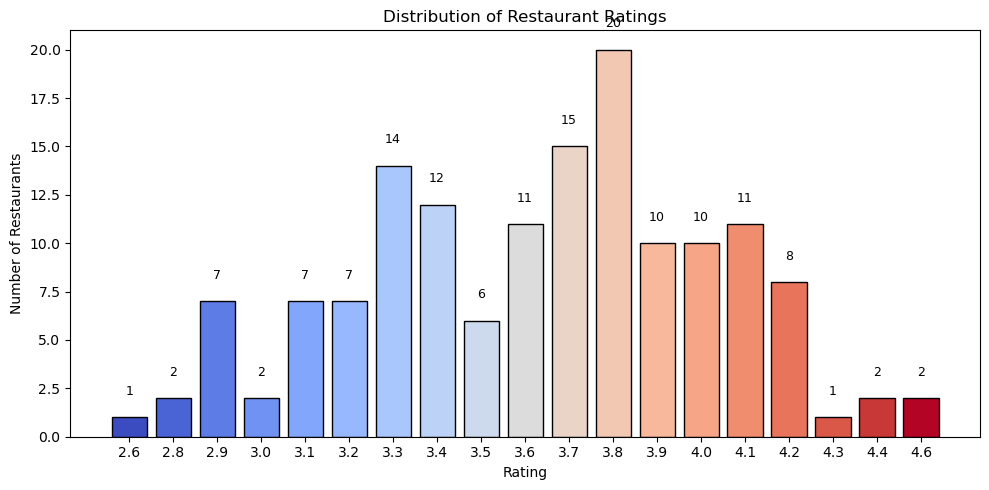

In [8]:
# step 7: What are the ratings that the majority of restaurants have received?

rating_counts = dataframe['rate'].value_counts().sort_index()
print("Ratings and their restaurant count:")
print(rating_counts)

plt.figure(figsize=(10, 5))
colors = plt.cm.coolwarm(np.linspace(0, 1, len(rating_counts)))
plt.bar(rating_counts.index.astype(str), rating_counts.values, color=colors, edgecolor='black')

for i, v in enumerate(rating_counts.values):
    plt.text(i, v + 1, str(v), ha='center', va='bottom', fontsize=9)

plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Restaurants')
plt.tight_layout()
plt.show()

In [9]:
# #Step 8: Zomato has observed that most couples order most of their food online. What is their average spending on each order?


avg_spending_online = dataframe[dataframe['online_order'] == 'Yes']['approx_cost(for two people)'].mean()
print(f"Average spending by couples ordering online: ₹{avg_spending_online:.2f}")

Average spending by couples ordering online: ₹510.34


In [10]:
# Step 9 : Which mode (online or offline) has received the maximum rating?

avg_rating_by_mode = dataframe.groupby('online_order')['rate'].mean()
print("Average rating by order mode (online/offline):")
print(avg_rating_by_mode)

best_mode = avg_rating_by_mode.idxmax()
best_rating = avg_rating_by_mode.max()
print(f"\n✅ Mode with highest average rating: {best_mode} ({best_rating:.2f})")

Average rating by order mode (online/offline):
online_order
No     3.487778
Yes    3.858621
Name: rate, dtype: float64

✅ Mode with highest average rating: Yes (3.86)


In [11]:
#Step 10: Which type of restaurant received more offline orders, so that Zomato can provide those customers with some good offers?

offline_orders = dataframe[dataframe['online_order'] == 'No']
offline_type_counts = offline_orders['listed_in(type)'].value_counts()
print("Restaurant types by offline orders:")
print(offline_type_counts)

most_offline_type = offline_type_counts.idxmax()
most_offline_count = offline_type_counts.max()
print(f"\n✅ Restaurant type with most offline orders: {most_offline_type} ({most_offline_count} orders)")

Restaurant types by offline orders:
listed_in(type)
Dining    77
Cafes      8
Buffet     3
other      2
Name: count, dtype: int64

✅ Restaurant type with most offline orders: Dining (77 orders)


# Summary: 

The majority of customers order from 'Dining' restaurants.

The total votes received by each type of restaurant are as follows: Buffet received 3028 votes, Cafes received 6434 votes, Dining received 20363 votes, and other received 9367 votes.

The rating that the majority of restaurants have received is 3.8.

The average spending on all online orders is approximately ₹510.34.

Online orders received the maximum average rating (3.86) compared to offline orders (3.49).

'Dining' restaurants received more offline orders.


## Data Analysis Key Findings:

The most frequent restaurant type ordered from is 'Dining', with a frequency of 110.

'Dining' restaurants have received the highest number of votes, totaling 20363.

The rating of 3.8 is the most frequent rating among restaurants.

The average spending on all online orders is ₹510.34.

Online orders have a higher average rating (3.86) compared to offline orders (3.49).

'Dining' restaurants received the most offline orders, with a count of 77.


## Insights or Next Steps:

Zomato should focus on promoting online ordering for all restaurant types, given its higher average rating.

Offering special promotions to customers ordering offline from 'Dining' restaurants could incentivize them to switch to online ordering or increase their order frequency.
